# PEC 2 — Visualización de Datos
## Gráfico de Burbujas | Gráfico de Gofre | Gráfico de Marimekko

**Fuentes de datos:**
- **Bubble Chart:** Paquete `gapminder` de Python (datos de Gapminder.org, año 2007). Licencia CC-BY. [https://www.gapminder.org/data/](https://www.gapminder.org/data/)
- **Waffle Chart:** Generación eléctrica en España 2023. Datos de Red Eléctrica de España (REE). [https://www.ree.es/es/datos/generacion/potencia-instalada](https://www.ree.es/es/datos/generacion/potencia-instalada) y [Informe de Renovables 2023](https://www.sistemaelectrico-ree.es/sites/default/files/2024-03/Informe_Renovables_2023.pdf)
- **Marimekko Chart:** Generación eléctrica por fuente en países de la UE, 2023. Datos de Eurostat (nrg_ind_peh). [https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Electricity_and_heat_statistics](https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Electricity_and_heat_statistics)

# Cargamos las librerías

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pywaffle import Waffle
from gapminder import gapminder

# Paleta de colores
Inspirada en [Coolors](https://coolors.co/264653-2a9d8f-e9c46a-f4a261-e76f51)

In [4]:
CONTINENT_COLORS = {
    "Asia":     "#2a9d8f",
    "Europe":   "#264653",
    "Americas": "#e76f51",
    "Africa":   "#f4a261",
    "Oceania":  "#6a4c93",
}

SOURCE_COLORS = {
    "Nuclear":     "#6a4c93",
    "Renovables":  "#2a9d8f",
    "Fósiles":     "#e76f51",
}

WAFFLE_COLORS = ["#2a9d8f", "#e9c46a", "#264653", "#6a4c93", "#e76f51", "#606c38", "#f4a261", "#999999", "#c9184a"]

# 1. Gráfico de Burbujas (Bubble Chart)

**Dataset:** Gapminder (año 2007, 142 países).  
**Fuente:** [Gapminder.org](https://www.gapminder.org/data/) — Datos libres bajo licencia CC-BY.  
**Variables:** PIB per cápita (eje X, escala logarítmica), esperanza de vida (eje Y), población (tamaño de burbuja), continente (color).

In [5]:
# Filtramos el año 2007 (último disponible en el paquete gapminder)
df_bubble = gapminder[gapminder["year"] == 2007].copy()
df_bubble.head(10)

,country,continent,year,lifeExp,pop,gdpPercap
11,Afghanistan,Asia,2007,43.828,31889923,974.580338
23,Albania,Europe,2007,76.423,3600523,5937.029526
35,Algeria,Africa,2007,72.301,33333216,6223.367465
47,Angola,Africa,2007,42.731,12420476,4797.231267
59,Argentina,Americas,2007,75.320,40301927,12779.379640
71,Australia,Oceania,2007,81.235,20434176,34435.367440
83,Austria,Europe,2007,79.829,8199783,36126.492700
95,Bahrain,Asia,2007,75.635,708573,29796.048340
107,Bangladesh,Asia,2007,64.062,150448339,1391.253792
119,Belgium,Europe,2007,79.441,10392226,33692.605080


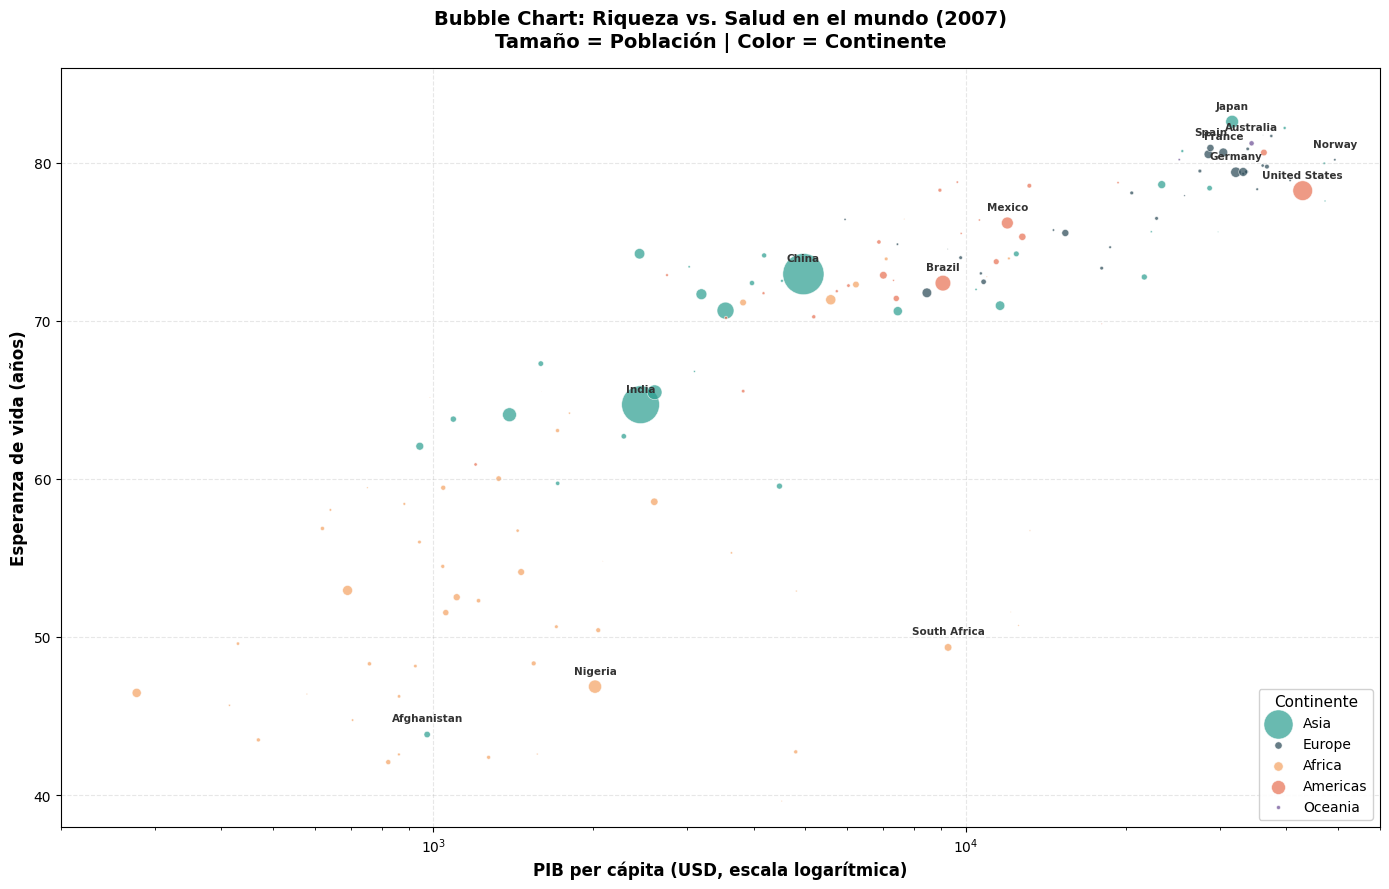

In [6]:
fig, ax = plt.subplots(figsize=(14, 9))

for continent in df_bubble["continent"].unique():
    subset = df_bubble[df_bubble["continent"] == continent]
    ax.scatter(
        subset["gdpPercap"],
        subset["lifeExp"],
        s=subset["pop"] / 1_500_000,
        c=CONTINENT_COLORS.get(continent, "#999999"),
        alpha=0.7,
        edgecolors="white",
        linewidth=0.5,
        label=continent,
    )

# Etiquetas para países relevantes
labels_to_show = ["China", "India", "United States", "Brazil", "Nigeria",
                   "Japan", "Germany", "Spain", "South Africa", "Australia",
                   "Mexico", "France", "Afghanistan", "Norway"]
for _, row in df_bubble.iterrows():
    if row["country"] in labels_to_show:
        ax.annotate(
            row["country"],
            (row["gdpPercap"], row["lifeExp"]),
            fontsize=7.5, ha="center", va="bottom",
            xytext=(0, 8), textcoords="offset points",
            fontweight="bold", color="#333333",
        )

ax.set_xscale("log")
ax.set_xlabel("PIB per cápita (USD, escala logarítmica)", fontsize=12, fontweight="bold")
ax.set_ylabel("Esperanza de vida (años)", fontsize=12, fontweight="bold")
ax.set_title("Bubble Chart: Riqueza vs. Salud en el mundo (2007)\nTamaño = Población | Color = Continente",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(title="Continente", fontsize=10, title_fontsize=11, loc="lower right", framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_xlim(200, 60000)
ax.set_ylim(38, 86)
plt.tight_layout()
plt.savefig("../images/bubble_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# 2. Gráfico de Gofre (Waffle Chart)

**Dataset:** Generación eléctrica en España, año 2023.  
**Fuente:** [Red Eléctrica de España (REE)](https://www.ree.es/es/datos/publicaciones/series-estadisticas-nacionales) — Datos públicos y gratuitos.  
Referencia: [Informe de Energías Renovables 2023](https://www.sistemaelectrico-ree.es/sites/default/files/2024-03/Informe_Renovables_2023.pdf).  
**Cada cuadrado = 1% de la generación eléctrica total.**

In [7]:
df_energy = pd.read_csv("../data/generacion_electrica_espana_2023.csv")
df_energy

,Fuente,Generacion_GWh,Porcentaje
0,Eólica,61083,23
1,Solar fotovoltaica,37328,14
2,Hidráulica,30297,11
3,Nuclear,55281,21
4,Ciclo combinado,44758,17
5,Cogeneración,16968,6
6,Otras renovables,10738,4
7,Carbón,4437,2
8,Resto,5990,2


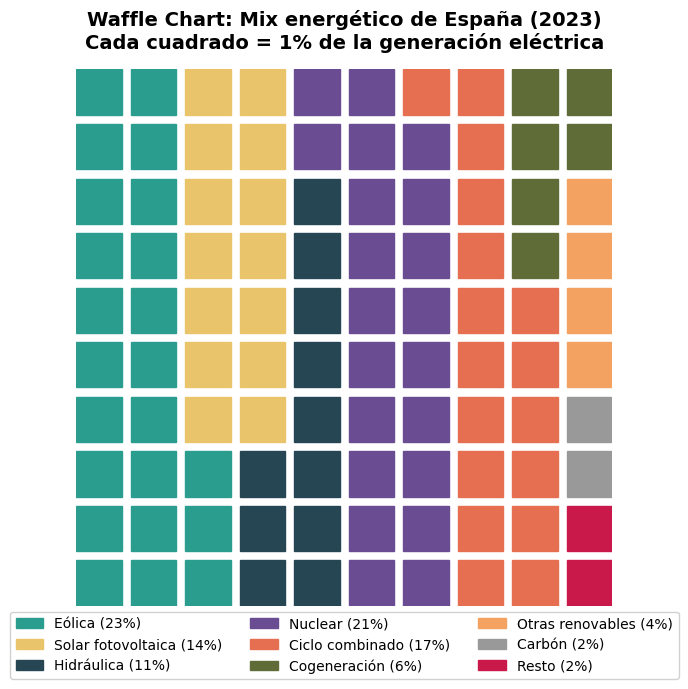

In [8]:
waffle_data = dict(zip(df_energy["Fuente"], df_energy["Porcentaje"]))

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    columns=10,
    values=waffle_data,
    colors=WAFFLE_COLORS[:len(waffle_data)],
    title={
        "label": "Waffle Chart: Mix energético de España (2023)\nCada cuadrado = 1% de la generación eléctrica",
        "loc": "center",
        "fontsize": 14,
        "fontweight": "bold",
        "pad": 15,
    },
    labels=[f"{k} ({v}%)" for k, v in waffle_data.items()],
    legend={
        "loc": "lower center",
        "bbox_to_anchor": (0.5, -0.15),
        "ncol": 3,
        "fontsize": 10,
        "framealpha": 0.9,
    },
    figsize=(10, 7),
    block_arranging_style="snake",
)
plt.tight_layout()
plt.savefig("../images/waffle_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# 3. Gráfico de Marimekko (Marimekko Chart)

**Dataset:** Generación eléctrica por tipo de fuente en 6 países de la UE, año 2023.  
**Fuente:** [Eurostat — Electricity and heat statistics (nrg_ind_peh)](https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Electricity_and_heat_statistics) — Datos públicos.  
**Anchura de cada columna** = peso del país en el total de generación de los 6 países.  
**Altura de cada segmento** = proporción de nuclear, renovables y fósiles dentro de cada país.

In [9]:
df_eu = pd.read_csv("../data/generacion_electrica_eu_2023.csv")
df_eu

,Pais,Fuente,Generacion_TWh
0,Francia,Nuclear,320
1,Francia,Renovables,135
2,Francia,Fósiles,50
3,Alemania,Nuclear,0
4,Alemania,Renovables,267
5,Alemania,Fósiles,220
6,España,Nuclear,55
7,España,Renovables,140
8,España,Fósiles,82
9,Italia,Nuclear,0


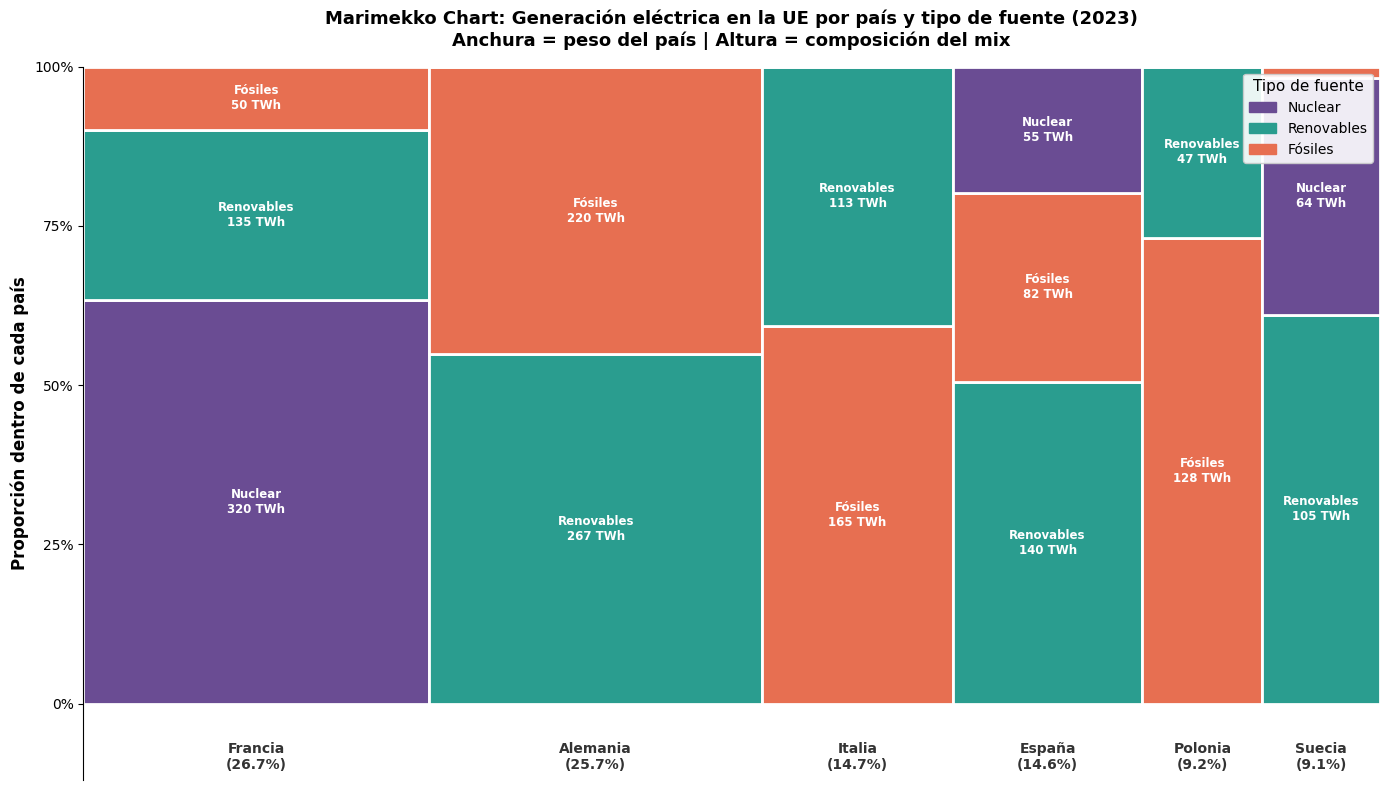

In [10]:
# Totales por país
country_totals = df_eu.groupby("Pais")["Generacion_TWh"].sum()
total_gen = country_totals.sum()

fig, ax = plt.subplots(figsize=(14, 8))

x_start = 0
country_order = country_totals.sort_values(ascending=False).index

for country in country_order:
    country_width = country_totals[country] / total_gen
    country_data = df_eu[df_eu["Pais"] == country].sort_values("Generacion_TWh", ascending=False)
    y_start = 0

    for _, row in country_data.iterrows():
        height = row["Generacion_TWh"] / country_totals[country]
        rect = plt.Rectangle(
            (x_start, y_start), country_width, height,
            facecolor=SOURCE_COLORS.get(row["Fuente"], "#cccccc"),
            edgecolor="white", linewidth=2,
        )
        ax.add_patch(rect)

        if height > 0.06 and country_width > 0.05:
            ax.text(
                x_start + country_width / 2,
                y_start + height / 2,
                f"{row['Fuente']}\n{row['Generacion_TWh']} TWh",
                ha="center", va="center",
                fontsize=8.5, color="white", fontweight="bold",
            )
        y_start += height

    pct = country_totals[country] / total_gen * 100
    ax.text(
        x_start + country_width / 2, -0.06,
        f"{country}\n({pct:.1f}%)",
        ha="center", va="top", fontsize=10, fontweight="bold", color="#333333",
    )
    x_start += country_width

legend_patches = [mpatches.Patch(color=c, label=cat) for cat, c in SOURCE_COLORS.items()]
ax.legend(handles=legend_patches, title="Tipo de fuente",
          loc="upper right", fontsize=10, title_fontsize=11, framealpha=0.9)

ax.set_xlim(0, 1)
ax.set_ylim(-0.12, 1)
ax.set_ylabel("Proporción dentro de cada país", fontsize=12, fontweight="bold")
ax.set_title("Marimekko Chart: Generación eléctrica en la UE por país y tipo de fuente (2023)\nAnchura = peso del país | Altura = composición del mix",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xticks([])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
plt.tight_layout()
plt.savefig("../images/marimekko_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()